# Clasificación y relevancia de variables — Sprint 2
---

## Estructura del notebook

| Sección | Descripción |
|---------|-------------|
| 0 | Importaciones y configuración global |
| 1 | Carga y preparación de datos |
| **EXP 1** | Todas las posiciones excepto porteros (GK) — 6 clases |
| **EXP 2** | Posiciones agrupadas simétricamente (LW+RW→Wing, LB+RB→Lateral) — 4 clases |
| Final | Entrenamiento sobre el dataset completo (train+test) para modelo robusto |

## 0. Importaciones y configuración

In [1]:
import os, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    train_test_split, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)
import xgboost as xgb

# ── Directorios de salida ────────────────────────────────────
OUT_ROOT = 'position_output'
for d in [OUT_ROOT, f'{OUT_ROOT}/exp1', f'{OUT_ROOT}/exp2', f'{OUT_ROOT}/final']:
    os.makedirs(d, exist_ok=True)

# ── Paleta de colores ────────────────────────────────────────
POS_COLORS = {
    'LW': '#3266ad', 'RW': '#7f77dd',
    'LB': '#d85a30', 'RB': '#ba7517',
    'CB': '#1d9e75',
    'LP': '#d4537e',
    # Grupos (Exp 2)
    'Wing':    '#3266ad',
    'Lateral': '#d85a30',
    'Central': '#1d9e75',
    'Pivote':  '#d4537e',
}

RANDOM_STATE = 42
print('Configuración lista.')

Configuración lista.


## 1. Carga y preparación de datos

In [ ]:
ruta_csv = 'EHF2024-M-AGGREGATED.csv'
df_raw = pd.read_csv(ruta_csv)

# ── Variables excluidas (RC, Time, 2+2) ──
COLS_DROP = ['Unnamed: 0', 'Team', 'No', 'Name',
             'scoring', 'topk', 'top1', 'R7', 'P7',
             'RC', 'Time', '2+2']         

FEATURE_COLS = [
    '7mPGoals', '7mPMissed',
    '6mCGoals', '6mCMissed',
    'WingGoals', 'WingMissed',
    'BTGoals',  'BTMissed',
    'FBGoals',  'FBMissed',
    'FTOGoals', 'FTOMissed',
    '9mGoals',  '9mMissed',
    '2M', 'AS', 'ST', 'BS', 'TO'
]
TARGET_COL = 'Position'

df_full = df_raw[FEATURE_COLS + [TARGET_COL]].copy()
df_full[TARGET_COL] = df_full[TARGET_COL].astype(str).str.strip()
df_full = df_full.dropna()

print(f'Dataset completo: {df_full.shape[0]} jugadores, {len(FEATURE_COLS)} variables')

Dataset completo: 427 jugadores, 19 variables


---

# ══════════════════════════════════════════
# EXPERIMENTO 1 — Todas las posiciones
# (LW, RW, LB, RB, CB, LP — 6 clases)
# ══════════════════════════════════════════

In [3]:
# ── Filtrar porteros ─────────────────────────────────────────
df_exp1 = df_full[df_full[TARGET_COL] != 'GK'].copy()
print(f'[EXP 1] Jugadores tras eliminar GK: {len(df_exp1)}')
print(df_exp1[TARGET_COL].value_counts())

X1 = df_exp1[FEATURE_COLS].values
y1_raw = df_exp1[TARGET_COL].values

le1 = LabelEncoder()
y1 = le1.fit_transform(y1_raw)
print('\nClases EXP 1:', le1.classes_)

[EXP 1] Jugadores tras eliminar GK: 371
Position
LB    83
LP    72
CB    64
RB    56
RW    50
LW    46
Name: count, dtype: int64

Clases EXP 1: ['CB' 'LB' 'LP' 'LW' 'RB' 'RW']


### 1.1 Split 80/20 estratificado + Estandarización

In [4]:
# IMPORTANTE: split PRIMERO, estandarización DESPUÉS (solo fit en train)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1
)

scaler1 = StandardScaler()              # z-score
X1_train_sc = scaler1.fit_transform(X1_train)   # fit solo en train
X1_test_sc  = scaler1.transform(X1_test)        # transform en test

print(f'Train: {X1_train_sc.shape[0]}  |  Test: {X1_test_sc.shape[0]}')

Train: 296  |  Test: 75


### 1.2 Funciones auxiliares

In [5]:
def metrics_table(y_true, y_pred, label_encoder, model_name, cv_mean=None, cv_std=None):
    """Devuelve DataFrame con métricas globales por modelo."""
    acc   = accuracy_score(y_true, y_pred)
    f1_w  = f1_score(y_true, y_pred, average='weighted')
    f1_m  = f1_score(y_true, y_pred, average='macro')
    prec  = precision_score(y_true, y_pred, average='weighted')
    rec   = recall_score(y_true, y_pred, average='weighted')
    row = {
        'Modelo': model_name,
        'Accuracy': round(acc, 4),
        'F1 (weighted)': round(f1_w, 4),
        'F1 (macro)': round(f1_m, 4),
        'Precision (weighted)': round(prec, 4),
        'Recall (weighted)': round(rec, 4),
    }
    return row


def per_class_table(y_true, y_pred, label_encoder, model_name):
    """Tabla de métricas por clase."""
    report = classification_report(
        y_true, y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )
    rows = []
    for cls in label_encoder.classes_:
        rows.append({
            'Modelo': model_name,
            'Clase': cls,
            'Precision': round(report[cls]['precision'], 4),
            'Recall':    round(report[cls]['recall'],    4),
            'F1-score':  round(report[cls]['f1-score'],  4),
        })
    return rows


def save_confusion_matrix(y_true, y_pred, label_encoder, model_name, filepath):
    """Guarda la matriz de confusión como imagen PNG."""
    cm   = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{model_name}  (acc={acc:.3f})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(filepath, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'   Guardada: {filepath}')


cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


### 1.3 Random Forest + GridSearchCV

In [6]:
# ── Grid de hiperparámetros ──────────────────────────────────
param_grid_rf = {
    'n_estimators':   [200, 500],
    'max_depth':      [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features':   ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
gs_rf1 = GridSearchCV(
    rf_base, param_grid_rf, cv=cv5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
gs_rf1.fit(X1_train_sc, y1_train)
rf1 = gs_rf1.best_estimator_

print(f'[EXP1 RF] Mejores hiperparámetros: {gs_rf1.best_params_}')
print(f'[EXP1 RF] CV accuracy (best):      {gs_rf1.best_score_:.4f}')

y1_pred_rf = rf1.predict(X1_test_sc)

# CV en train con el mejor estimador
cv_rf1 = cross_val_score(rf1, X1_train_sc, y1_train, cv=cv5, scoring='accuracy')

print(f'[EXP1 RF] Test accuracy: {accuracy_score(y1_test, y1_pred_rf):.4f}')
print(classification_report(y1_test, y1_pred_rf, target_names=le1.classes_))

[EXP1 RF] Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 200}
[EXP1 RF] CV accuracy (best):      0.4798
[EXP1 RF] Test accuracy: 0.4133
              precision    recall  f1-score   support

          CB       0.40      0.31      0.35        13
          LB       0.39      0.41      0.40        17
          LP       0.79      0.73      0.76        15
          LW       0.26      0.56      0.36         9
          RB       0.14      0.09      0.11        11
          RW       0.43      0.30      0.35        10

    accuracy                           0.41        75
   macro avg       0.40      0.40      0.39        75
weighted avg       0.42      0.41      0.41        75



### 1.4 XGBoost + GridSearchCV

In [7]:
param_grid_xgb = {
    'n_estimators':   [200, 500],
    'max_depth':      [4, 6, 8],
    'learning_rate':  [0.01, 0.05, 0.1],
    'subsample':      [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

xgb_base = xgb.XGBClassifier(
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
gs_xgb1 = GridSearchCV(
    xgb_base, param_grid_xgb, cv=cv5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
gs_xgb1.fit(X1_train_sc, y1_train)
xgb1 = gs_xgb1.best_estimator_

print(f'[EXP1 XGB] Mejores hiperparámetros: {gs_xgb1.best_params_}')
print(f'[EXP1 XGB] CV accuracy (best):      {gs_xgb1.best_score_:.4f}')

y1_pred_xgb = xgb1.predict(X1_test_sc)
cv_xgb1 = cross_val_score(xgb1, X1_train_sc, y1_train, cv=cv5, scoring='accuracy')

print(f'[EXP1 XGB] Test accuracy: {accuracy_score(y1_test, y1_pred_xgb):.4f}')
print(classification_report(y1_test, y1_pred_xgb, target_names=le1.classes_))

[EXP1 XGB] Mejores hiperparámetros: {'colsample_bytree': 0.9, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.9}
[EXP1 XGB] CV accuracy (best):      0.4762
[EXP1 XGB] Test accuracy: 0.4533
              precision    recall  f1-score   support

          CB       0.67      0.31      0.42        13
          LB       0.38      0.76      0.51        17
          LP       0.79      0.73      0.76        15
          LW       0.30      0.33      0.32         9
          RB       0.25      0.09      0.13        11
          RW       0.29      0.20      0.24        10

    accuracy                           0.45        75
   macro avg       0.45      0.40      0.40        75
weighted avg       0.47      0.45      0.43        75



### 1.5 SVM + GridSearchCV

In [8]:
param_grid_svm = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'poly']
}

svm_base = SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True)
gs_svm1 = GridSearchCV(
    svm_base, param_grid_svm, cv=cv5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
gs_svm1.fit(X1_train_sc, y1_train)
svm1 = gs_svm1.best_estimator_

print(f'[EXP1 SVM] Mejores hiperparámetros: {gs_svm1.best_params_}')
print(f'[EXP1 SVM] CV accuracy (best):      {gs_svm1.best_score_:.4f}')

y1_pred_svm = svm1.predict(X1_test_sc)
cv_svm1 = cross_val_score(svm1, X1_train_sc, y1_train, cv=cv5, scoring='accuracy')

print(f'[EXP1 SVM] Test accuracy: {accuracy_score(y1_test, y1_pred_svm):.4f}')
print(classification_report(y1_test, y1_pred_svm, target_names=le1.classes_))

[EXP1 SVM] Mejores hiperparámetros: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
[EXP1 SVM] CV accuracy (best):      0.4766
[EXP1 SVM] Test accuracy: 0.3867
              precision    recall  f1-score   support

          CB       0.44      0.31      0.36        13
          LB       0.30      0.35      0.32        17
          LP       0.91      0.67      0.77        15
          LW       0.24      0.56      0.33         9
          RB       0.14      0.09      0.11        11
          RW       0.43      0.30      0.35        10

    accuracy                           0.39        75
   macro avg       0.41      0.38      0.38        75
weighted avg       0.43      0.39      0.39        75



### 1.6 Red Neuronal (MLP) + GridSearchCV

In [9]:
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (128, 64), (256, 128, 64)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [0.001, 0.01]
}

mlp_base = MLPClassifier(
    max_iter=500, early_stopping=True,
    random_state=RANDOM_STATE
)
gs_mlp1 = GridSearchCV(
    mlp_base, param_grid_mlp, cv=cv5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
gs_mlp1.fit(X1_train_sc, y1_train)
mlp1 = gs_mlp1.best_estimator_

print(f'[EXP1 MLP] Mejores hiperparámetros: {gs_mlp1.best_params_}')
print(f'[EXP1 MLP] CV accuracy (best):      {gs_mlp1.best_score_:.4f}')

y1_pred_mlp = mlp1.predict(X1_test_sc)
cv_mlp1 = cross_val_score(mlp1, X1_train_sc, y1_train, cv=cv5, scoring='accuracy')

print(f'[EXP1 MLP] Test accuracy: {accuracy_score(y1_test, y1_pred_mlp):.4f}')
print(classification_report(y1_test, y1_pred_mlp, target_names=le1.classes_))

[EXP1 MLP] Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001}
[EXP1 MLP] CV accuracy (best):      0.4929
[EXP1 MLP] Test accuracy: 0.4533
              precision    recall  f1-score   support

          CB       0.33      0.23      0.27        13
          LB       0.43      0.76      0.55        17
          LP       0.80      0.80      0.80        15
          LW       0.31      0.44      0.36         9
          RB       0.33      0.09      0.14        11
          RW       0.20      0.10      0.13        10

    accuracy                           0.45        75
   macro avg       0.40      0.41      0.38        75
weighted avg       0.43      0.45      0.42        75



### 1.7 Matrices de confusión

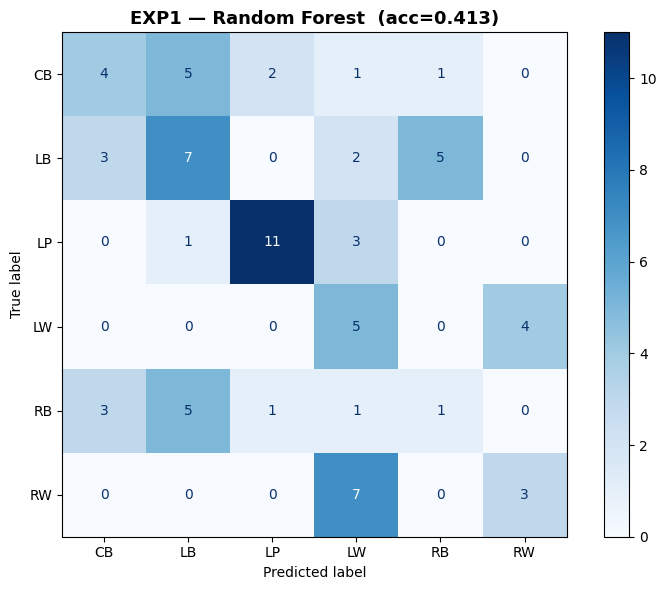

   Guardada: position_output/exp1/cm_random_forest.png


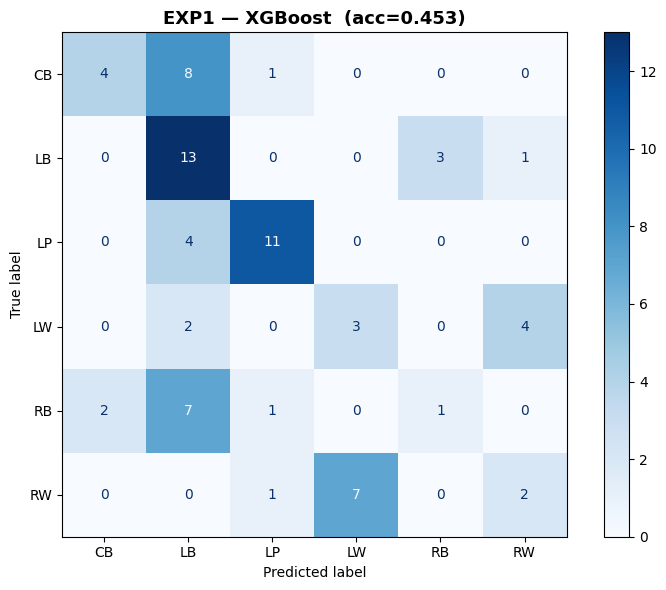

   Guardada: position_output/exp1/cm_xgboost.png


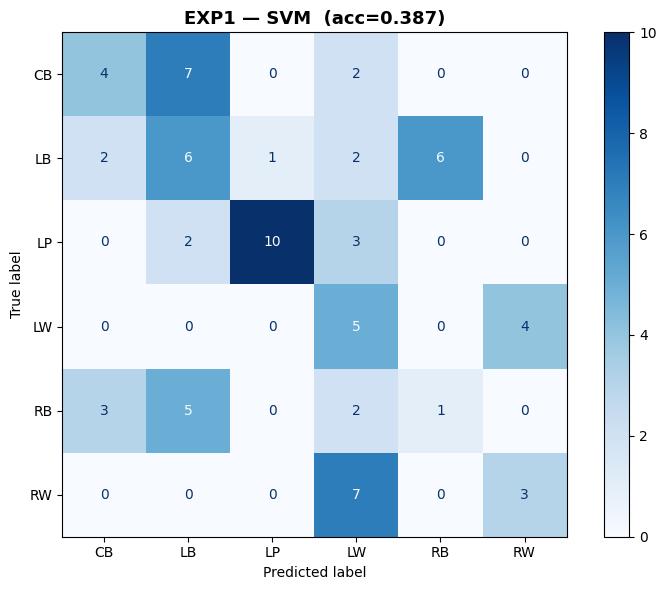

   Guardada: position_output/exp1/cm_svm.png


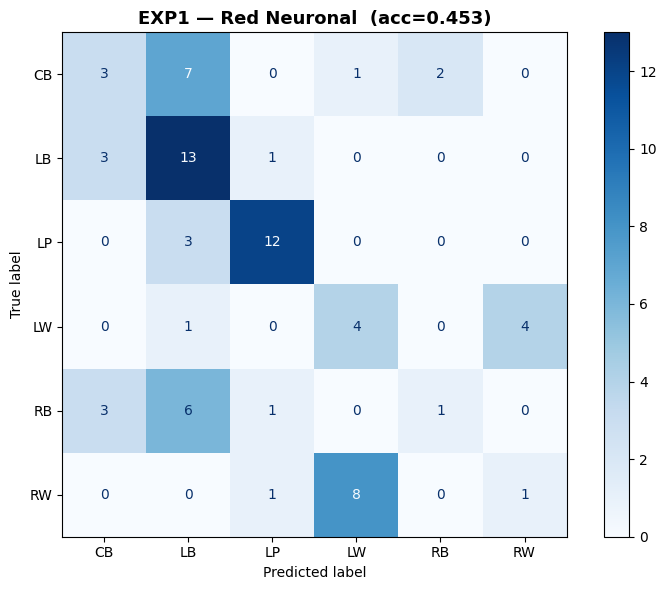

   Guardada: position_output/exp1/cm_red_neuronal.png


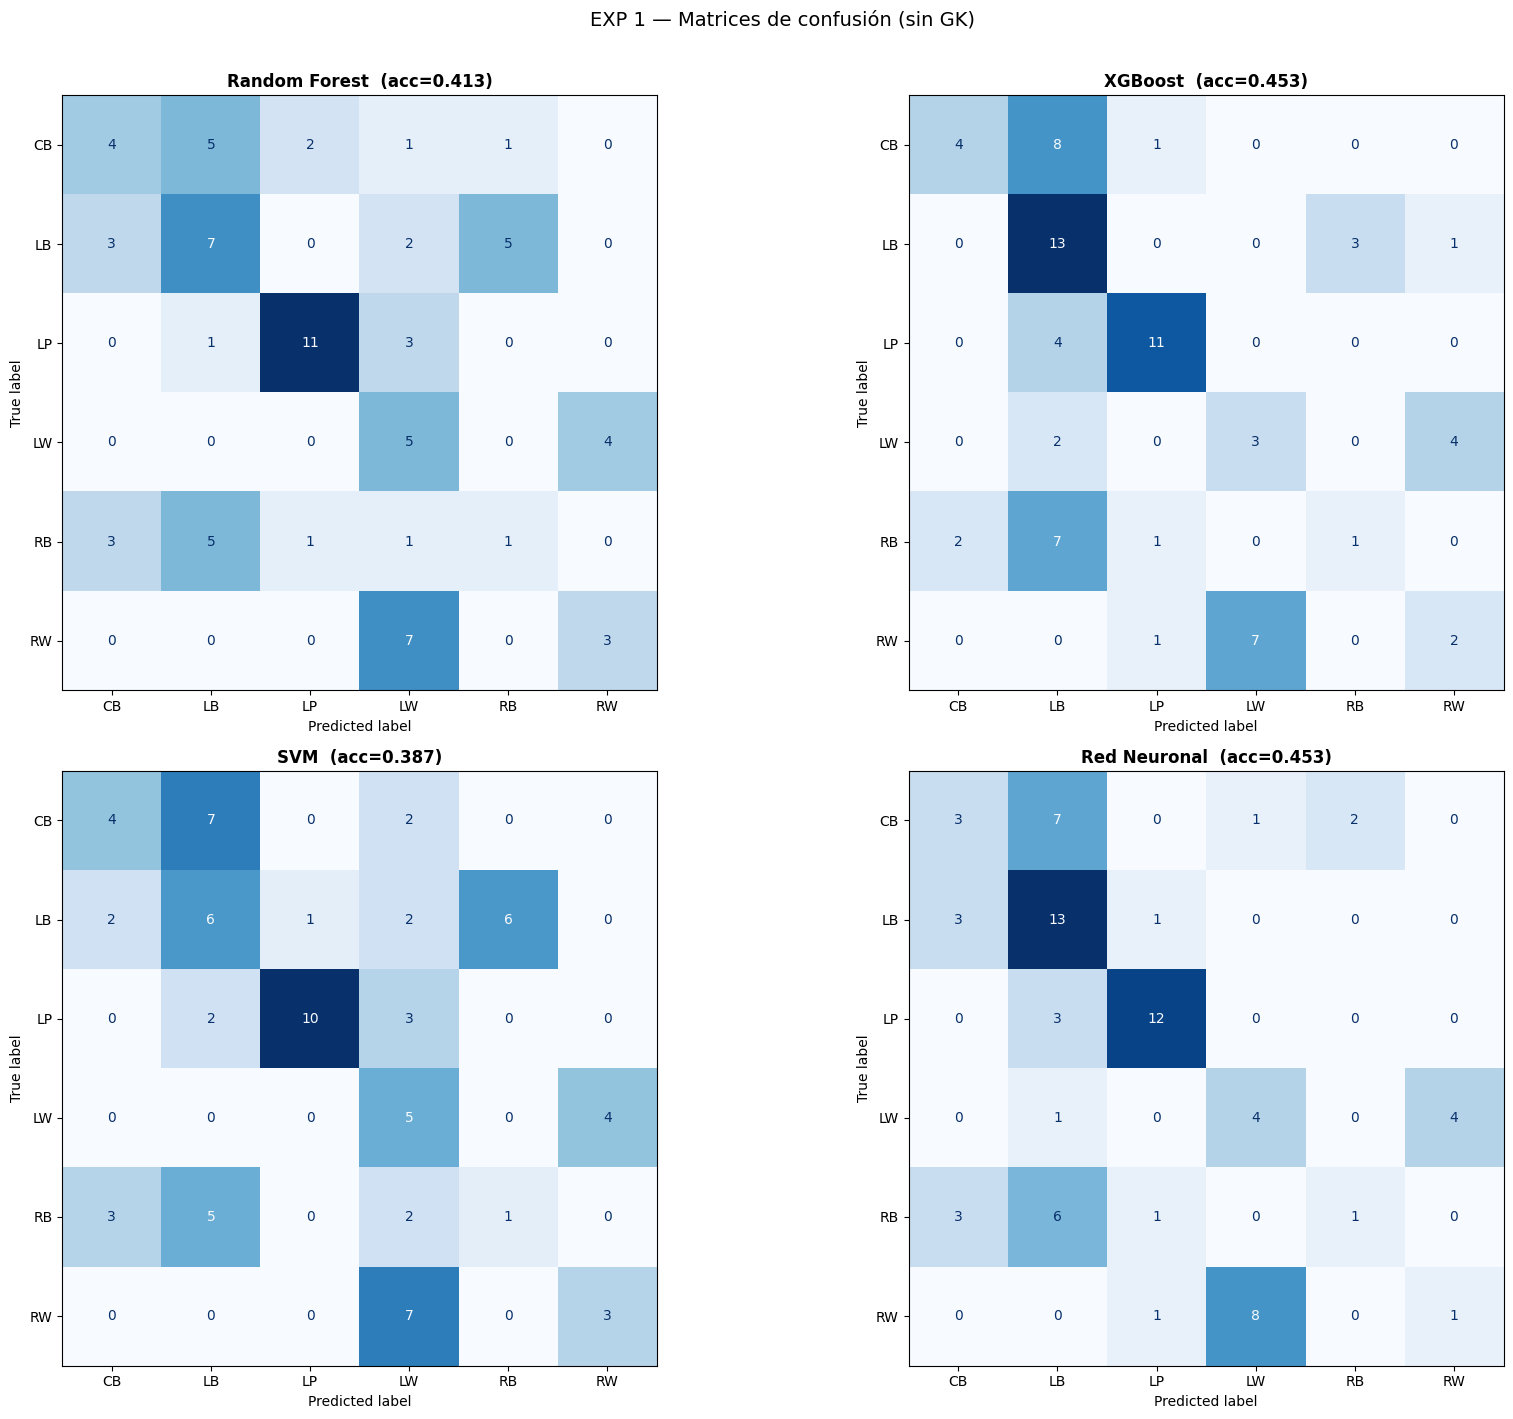

Guardada figura combinada: position_output/exp1/confusion_matrices_all.png


In [10]:
models_exp1 = [
    ('Random Forest', y1_pred_rf),
    ('XGBoost',       y1_pred_xgb),
    ('SVM',           y1_pred_svm),
    ('Red Neuronal',  y1_pred_mlp),
]

for name, preds in models_exp1:
    path = f"{OUT_ROOT}/exp1/cm_{name.replace(' ','_').lower()}.png"
    save_confusion_matrix(y1_test, preds, le1, f'EXP1 — {name}', path)

# Figura combinada de las 4 matrices
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
for ax, (name, preds) in zip(axes, models_exp1):
    cm = confusion_matrix(y1_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le1.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y1_test, preds)
    ax.set_title(f'{name}  (acc={acc:.3f})', fontsize=12, fontweight='bold')
plt.suptitle('EXP 1 — Matrices de confusión (sin GK)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp1/confusion_matrices_all.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Guardada figura combinada: {OUT_ROOT}/exp1/confusion_matrices_all.png")

### 1.8 Tabla de métricas — EXP 1

In [11]:
cvs1 = [
    (cv_rf1.mean(),  cv_rf1.std()),
    (cv_xgb1.mean(), cv_xgb1.std()),
    (cv_svm1.mean(), cv_svm1.std()),
    (cv_mlp1.mean(), cv_mlp1.std()),
]

rows_exp1 = []
for (name, preds), (cv_m, cv_s) in zip(models_exp1, cvs1):
    rows_exp1.append(metrics_table(y1_test, preds, le1, name, cv_m, cv_s))

df_metrics_exp1 = pd.DataFrame(rows_exp1).set_index('Modelo')
print('=== EXP 1 — Métricas globales ===')
display(df_metrics_exp1)
df_metrics_exp1.to_csv(f'{OUT_ROOT}/exp1/metrics_global.csv')

# Tabla por clase
rows_class_exp1 = []
for name, preds in models_exp1:
    rows_class_exp1.extend(per_class_table(y1_test, preds, le1, name))
df_class_exp1 = pd.DataFrame(rows_class_exp1)
print('\n=== EXP 1 — Métricas por clase ===')
display(df_class_exp1)
df_class_exp1.to_csv(f'{OUT_ROOT}/exp1/metrics_per_class.csv', index=False)

=== EXP 1 — Métricas globales ===


,Accuracy,F1 (weighted),F1 (macro),Precision (weighted),Recall (weighted)
Modelo,,,,,
Random Forest,0.4133,0.4089,0.3879,0.4243,0.4133
XGBoost,0.4533,0.4291,0.3956,0.4701,0.4533
SVM,0.3867,0.3937,0.3758,0.4335,0.3867
Red Neuronal,0.4533,0.4150,0.3776,0.4285,0.4533



=== EXP 1 — Métricas por clase ===


,Modelo,Clase,Precision,Recall,F1-score
0,Random Forest,CB,0.4000,0.3077,0.3478
1,Random Forest,LB,0.3889,0.4118,0.4000
2,Random Forest,LP,0.7857,0.7333,0.7586
3,Random Forest,LW,0.2632,0.5556,0.3571
4,Random Forest,RB,0.1429,0.0909,0.1111
5,Random Forest,RW,0.4286,0.3000,0.3529
6,XGBoost,CB,0.6667,0.3077,0.4211
7,XGBoost,LB,0.3824,0.7647,0.5098
8,XGBoost,LP,0.7857,0.7333,0.7586
9,XGBoost,LW,0.3000,0.3333,0.3158


### 1.9 Análisis SHAP — EXP 1 (mejor modelo)

Mejor modelo EXP1: XGBoost  (0.4533)


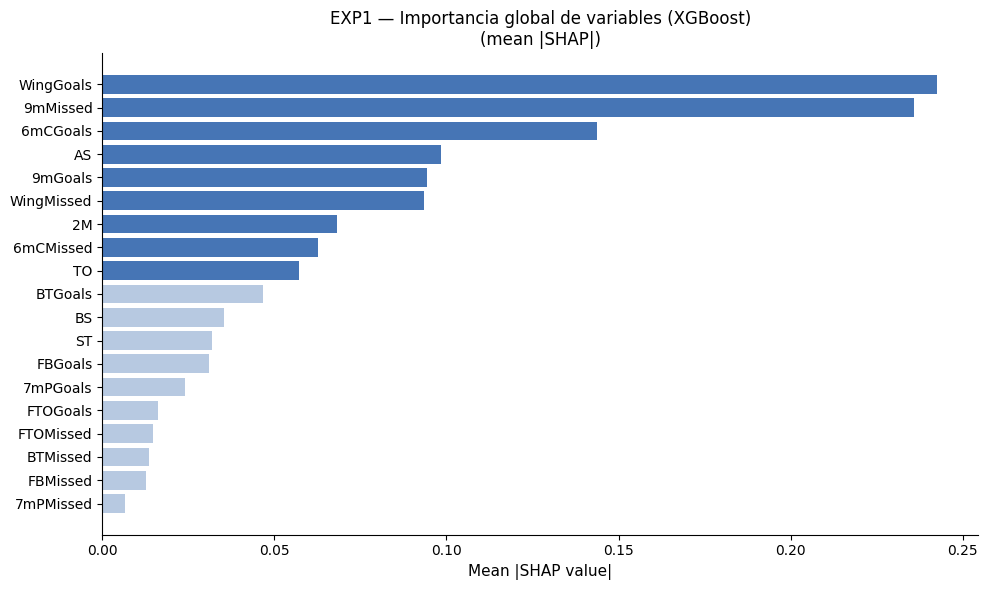


Top 10 variables más importantes (EXP1):


,mean_abs_shap
WingGoals,0.2424
9mMissed,0.2358
6mCGoals,0.1438
AS,0.0984
9mGoals,0.0943
WingMissed,0.0934
2M,0.0682
6mCMissed,0.0626
TO,0.0572
BTGoals,0.0466


In [12]:
# Elegir el mejor modelo por test accuracy
accs1 = {name: accuracy_score(y1_test, p) for name, p in models_exp1}
best_name1 = max(accs1, key=accs1.get)
best_model1_map = {
    'Random Forest': rf1,
    'XGBoost':       xgb1,
}
print(f'Mejor modelo EXP1: {best_name1}  ({accs1[best_name1]:.4f})')

# SHAP solo disponible directamente para modelos de árbol
shap_model1_name = best_name1 if best_name1 in best_model1_map else 'XGBoost'
shap_model1 = best_model1_map[shap_model1_name]

X1_all_sc = scaler1.transform(X1)
explainer1 = shap.TreeExplainer(shap_model1)
shap_vals1 = explainer1.shap_values(X1_all_sc)

# Importancia global
if isinstance(shap_vals1, list):
    global_shap1 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals1], axis=0)
else:
    global_shap1 = np.abs(shap_vals1).mean(axis=(0, 2)) if shap_vals1.ndim == 3 else np.abs(shap_vals1).mean(axis=0)

shap_imp1 = pd.Series(global_shap1, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#3266ad' if v > shap_imp1.median() else '#b0c4de' for v in shap_imp1.values]
ax.barh(shap_imp1.index[::-1], shap_imp1.values[::-1], color=colors_bar[::-1], alpha=0.9)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title(f'EXP1 — Importancia global de variables ({shap_model1_name})\n(mean |SHAP|)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp1/shap_global_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('\nTop 10 variables más importantes (EXP1):')
display(shap_imp1.head(10).to_frame('mean_abs_shap').round(4))

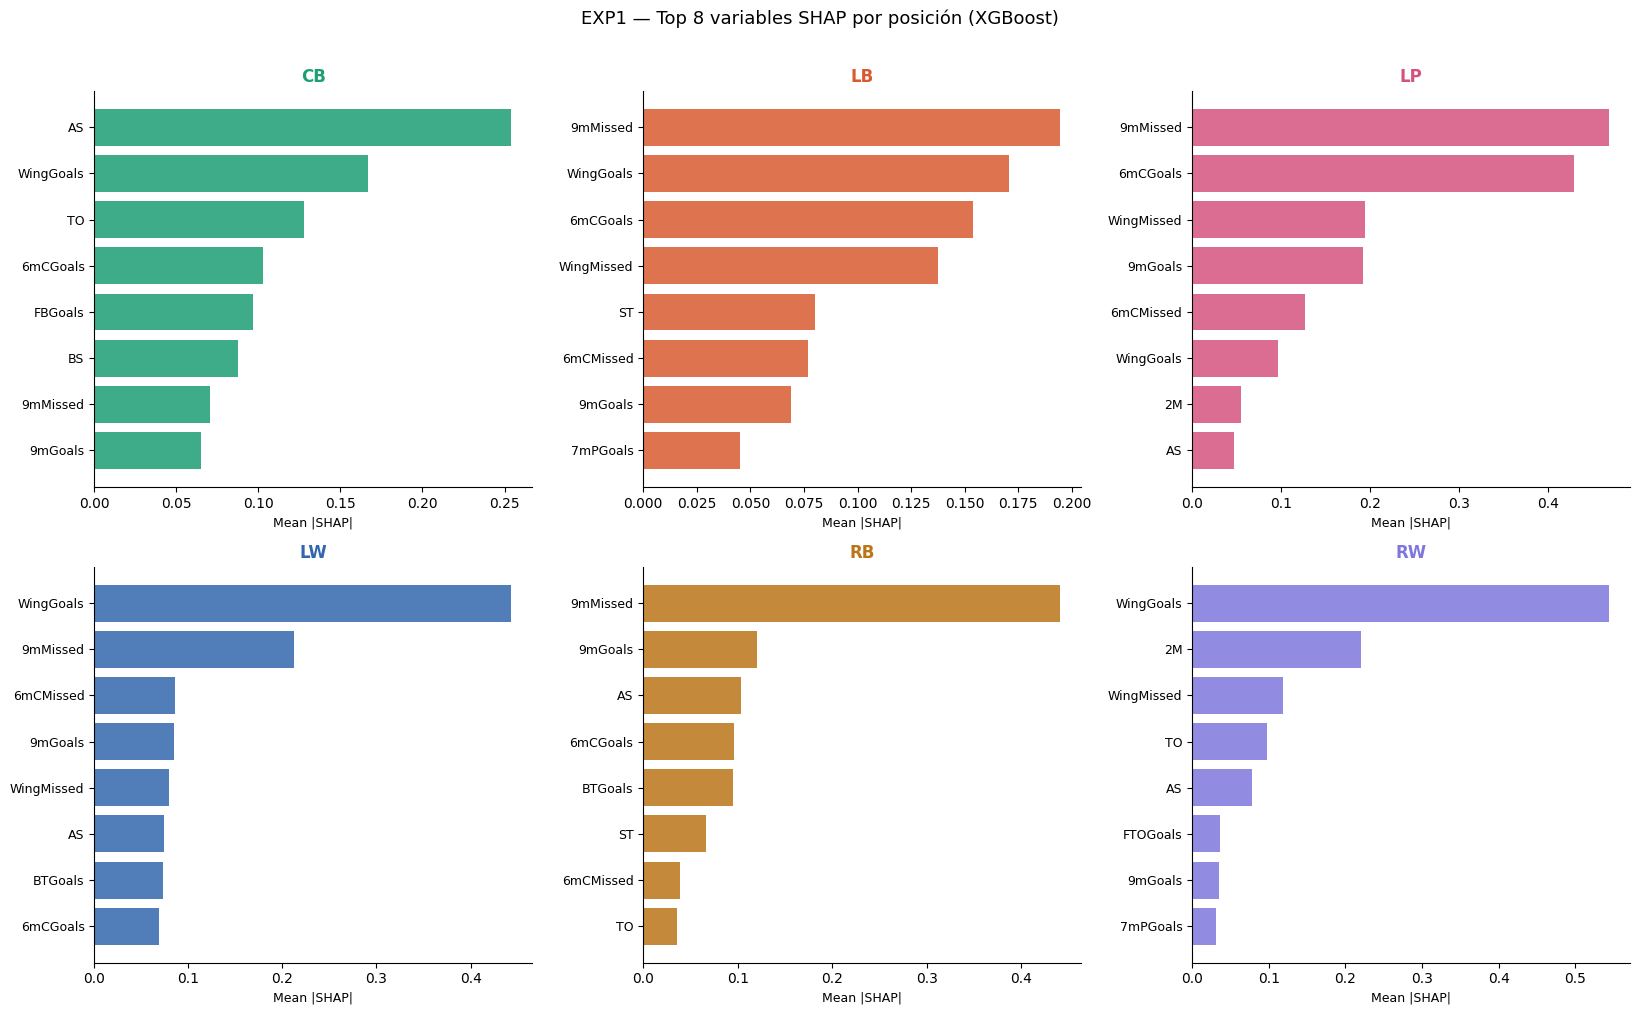

Guardada: position_output/exp1/shap_per_position.png


In [13]:
# SHAP por posición — EXP1
if isinstance(shap_vals1, list):
    shap_list1 = shap_vals1
elif shap_vals1.ndim == 3:
    shap_list1 = [shap_vals1[:, :, i] for i in range(shap_vals1.shape[2])]
else:
    shap_list1 = [shap_vals1]

classes1 = le1.classes_
TOP_N = 8
n_cls1 = len(classes1)
n_cols1 = min(n_cls1, 3)
n_rows1 = math.ceil(n_cls1 / n_cols1)

fig, axes = plt.subplots(n_rows1, n_cols1, figsize=(n_cols1*5.5, n_rows1*5))
axes = np.array(axes).flatten()

for idx, cls in enumerate(classes1):
    sv = shap_list1[idx]
    mean_abs = np.abs(sv).mean(axis=0)
    importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
    top_vars = importance.head(TOP_N)
    color = POS_COLORS.get(cls, '#888')
    ax = axes[idx]
    ax.barh(range(TOP_N), top_vars.values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.set_title(f'{cls}', fontsize=12, fontweight='bold', color=color)
    ax.spines[['top', 'right']].set_visible(False)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'EXP1 — Top {TOP_N} variables SHAP por posición ({shap_model1_name})',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp1/shap_per_position.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp1/shap_per_position.png')

---

# ══════════════════════════════════════════
# EXPERIMENTO 2 — Posiciones agrupadas
# LW+RW → Wing | LB+RB → Lateral | CB → Central | LP → Pivote
# (4 clases)
# ══════════════════════════════════════════

In [14]:
# ── Mapeo de posiciones equivalentes ────────────────────────
POS_MAP = {
    'LW': 'Wing',    'RW': 'Wing',
    'LB': 'Lateral', 'RB': 'Lateral',
    'CB': 'Central',
    'LP': 'Pivote',
}

df_exp2 = df_full[df_full[TARGET_COL] != 'GK'].copy()
df_exp2['Grupo'] = df_exp2[TARGET_COL].map(POS_MAP)

print('[EXP 2] Distribución de grupos:')
print(df_exp2['Grupo'].value_counts())

X2 = df_exp2[FEATURE_COLS].values
y2_raw = df_exp2['Grupo'].values

le2 = LabelEncoder()
y2 = le2.fit_transform(y2_raw)
print('\nClases EXP 2:', le2.classes_)

[EXP 2] Distribución de grupos:
Grupo
Lateral    139
Wing        96
Pivote      72
Central     64
Name: count, dtype: int64

Clases EXP 2: ['Central' 'Lateral' 'Pivote' 'Wing']


### 2.1 Split 80/20 estratificado + Estandarización z-score (sin fuga de datos)

In [15]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)

scaler2 = StandardScaler()              # z-score
X2_train_sc = scaler2.fit_transform(X2_train)   # fit SOLO en train
X2_test_sc  = scaler2.transform(X2_test)        # transform en test

print(f'Train: {X2_train_sc.shape[0]}  |  Test: {X2_test_sc.shape[0]}')

Train: 296  |  Test: 75


### 2.2 Random Forest + GridSearchCV

In [16]:
gs_rf2 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_rf2.fit(X2_train_sc, y2_train)
rf2 = gs_rf2.best_estimator_

print(f'[EXP2 RF] Mejores hiperparámetros: {gs_rf2.best_params_}')
y2_pred_rf = rf2.predict(X2_test_sc)
cv_rf2 = cross_val_score(rf2, X2_train_sc, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 RF] Test accuracy: {accuracy_score(y2_test, y2_pred_rf):.4f}')
print(classification_report(y2_test, y2_pred_rf, target_names=le2.classes_))

[EXP2 RF] Mejores hiperparámetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
[EXP2 RF] Test accuracy: 0.7200
              precision    recall  f1-score   support

     Central       0.67      0.46      0.55        13
     Lateral       0.76      0.68      0.72        28
      Pivote       0.57      0.87      0.68        15
        Wing       0.89      0.84      0.86        19

    accuracy                           0.72        75
   macro avg       0.72      0.71      0.70        75
weighted avg       0.74      0.72      0.72        75



### 2.3 XGBoost + GridSearchCV

In [17]:
gs_xgb2 = GridSearchCV(
    xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    param_grid_xgb, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_xgb2.fit(X2_train_sc, y2_train)
xgb2 = gs_xgb2.best_estimator_

print(f'[EXP2 XGB] Mejores hiperparámetros: {gs_xgb2.best_params_}')
y2_pred_xgb = xgb2.predict(X2_test_sc)
cv_xgb2 = cross_val_score(xgb2, X2_train_sc, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 XGB] Test accuracy: {accuracy_score(y2_test, y2_pred_xgb):.4f}')
print(classification_report(y2_test, y2_pred_xgb, target_names=le2.classes_))

[EXP2 XGB] Mejores hiperparámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.7}
[EXP2 XGB] Test accuracy: 0.7333
              precision    recall  f1-score   support

     Central       0.67      0.15      0.25        13
     Lateral       0.62      0.89      0.74        28
      Pivote       0.92      0.80      0.86        15
        Wing       0.84      0.84      0.84        19

    accuracy                           0.73        75
   macro avg       0.76      0.67      0.67        75
weighted avg       0.75      0.73      0.70        75



### 2.4 SVM + GridSearchCV

In [18]:
gs_svm2 = GridSearchCV(
    SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True),
    param_grid_svm, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_svm2.fit(X2_train_sc, y2_train)
svm2 = gs_svm2.best_estimator_

print(f'[EXP2 SVM] Mejores hiperparámetros: {gs_svm2.best_params_}')
y2_pred_svm = svm2.predict(X2_test_sc)
cv_svm2 = cross_val_score(svm2, X2_train_sc, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 SVM] Test accuracy: {accuracy_score(y2_test, y2_pred_svm):.4f}')
print(classification_report(y2_test, y2_pred_svm, target_names=le2.classes_))

[EXP2 SVM] Mejores hiperparámetros: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
[EXP2 SVM] Test accuracy: 0.6400
              precision    recall  f1-score   support

     Central       0.41      0.69      0.51        13
     Lateral       0.76      0.46      0.58        28
      Pivote       0.53      0.67      0.59        15
        Wing       0.94      0.84      0.89        19

    accuracy                           0.64        75
   macro avg       0.66      0.67      0.64        75
weighted avg       0.70      0.64      0.65        75



### 2.5 Red Neuronal (MLP) + GridSearchCV

In [19]:
gs_mlp2 = GridSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE),
    param_grid_mlp, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_mlp2.fit(X2_train_sc, y2_train)
mlp2 = gs_mlp2.best_estimator_

print(f'[EXP2 MLP] Mejores hiperparámetros: {gs_mlp2.best_params_}')
y2_pred_mlp = mlp2.predict(X2_test_sc)
cv_mlp2 = cross_val_score(mlp2, X2_train_sc, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 MLP] Test accuracy: {accuracy_score(y2_test, y2_pred_mlp):.4f}')
print(classification_report(y2_test, y2_pred_mlp, target_names=le2.classes_))

[EXP2 MLP] Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}
[EXP2 MLP] Test accuracy: 0.7200
              precision    recall  f1-score   support

     Central       0.00      0.00      0.00        13
     Lateral       0.59      0.93      0.72        28
      Pivote       1.00      0.80      0.89        15
        Wing       0.89      0.84      0.86        19

    accuracy                           0.72        75
   macro avg       0.62      0.64      0.62        75
weighted avg       0.65      0.72      0.67        75



### 2.6 Matrices de confusión — EXP 2

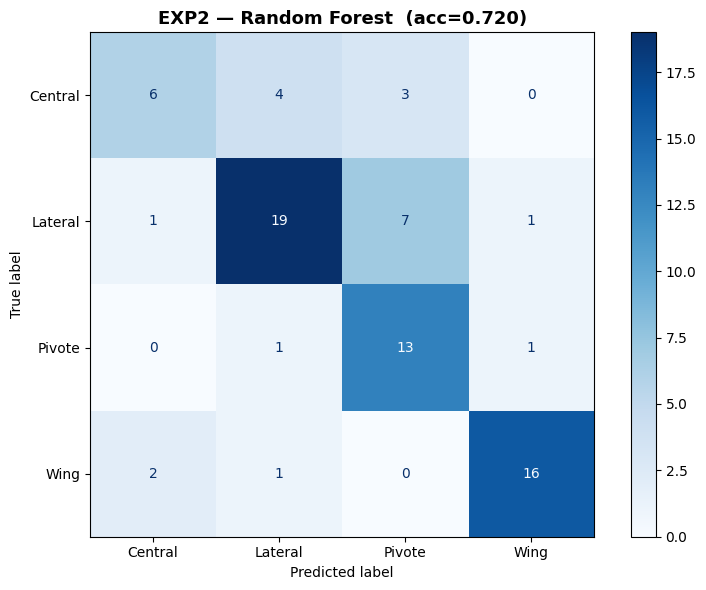

   Guardada: position_output/exp2/cm_random_forest.png


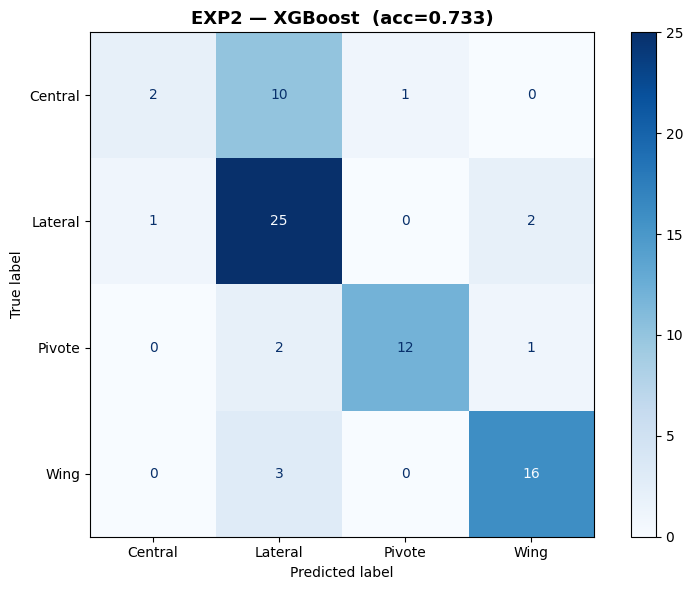

   Guardada: position_output/exp2/cm_xgboost.png


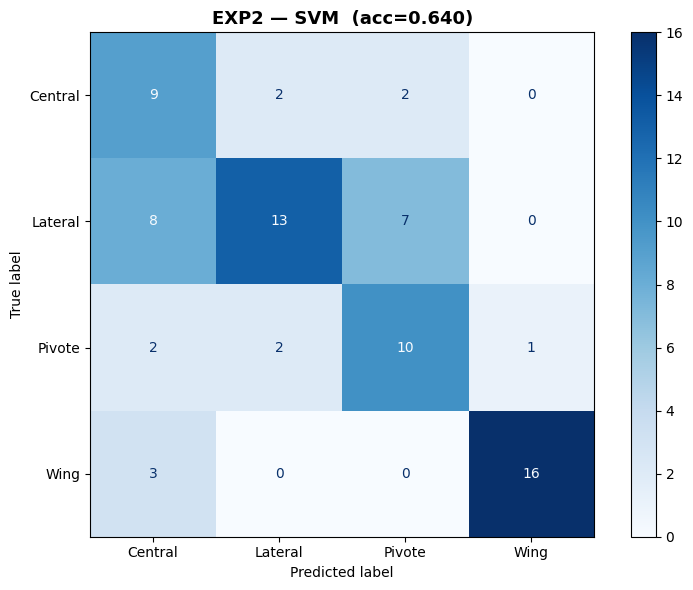

   Guardada: position_output/exp2/cm_svm.png


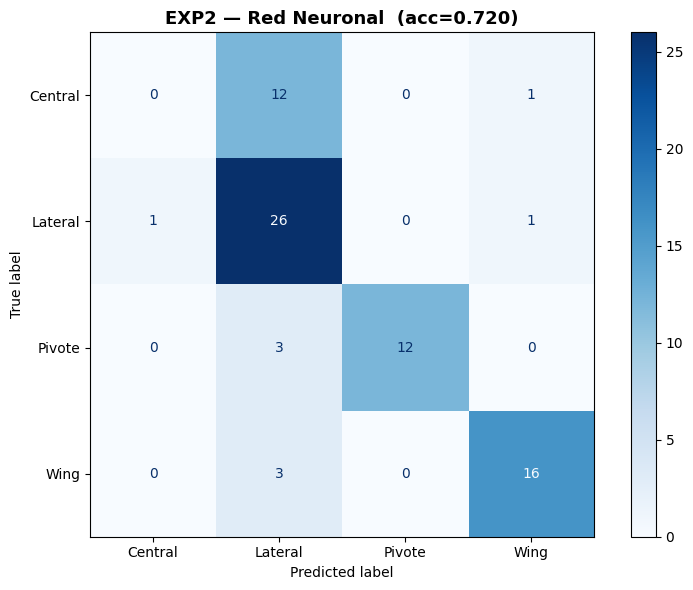

   Guardada: position_output/exp2/cm_red_neuronal.png


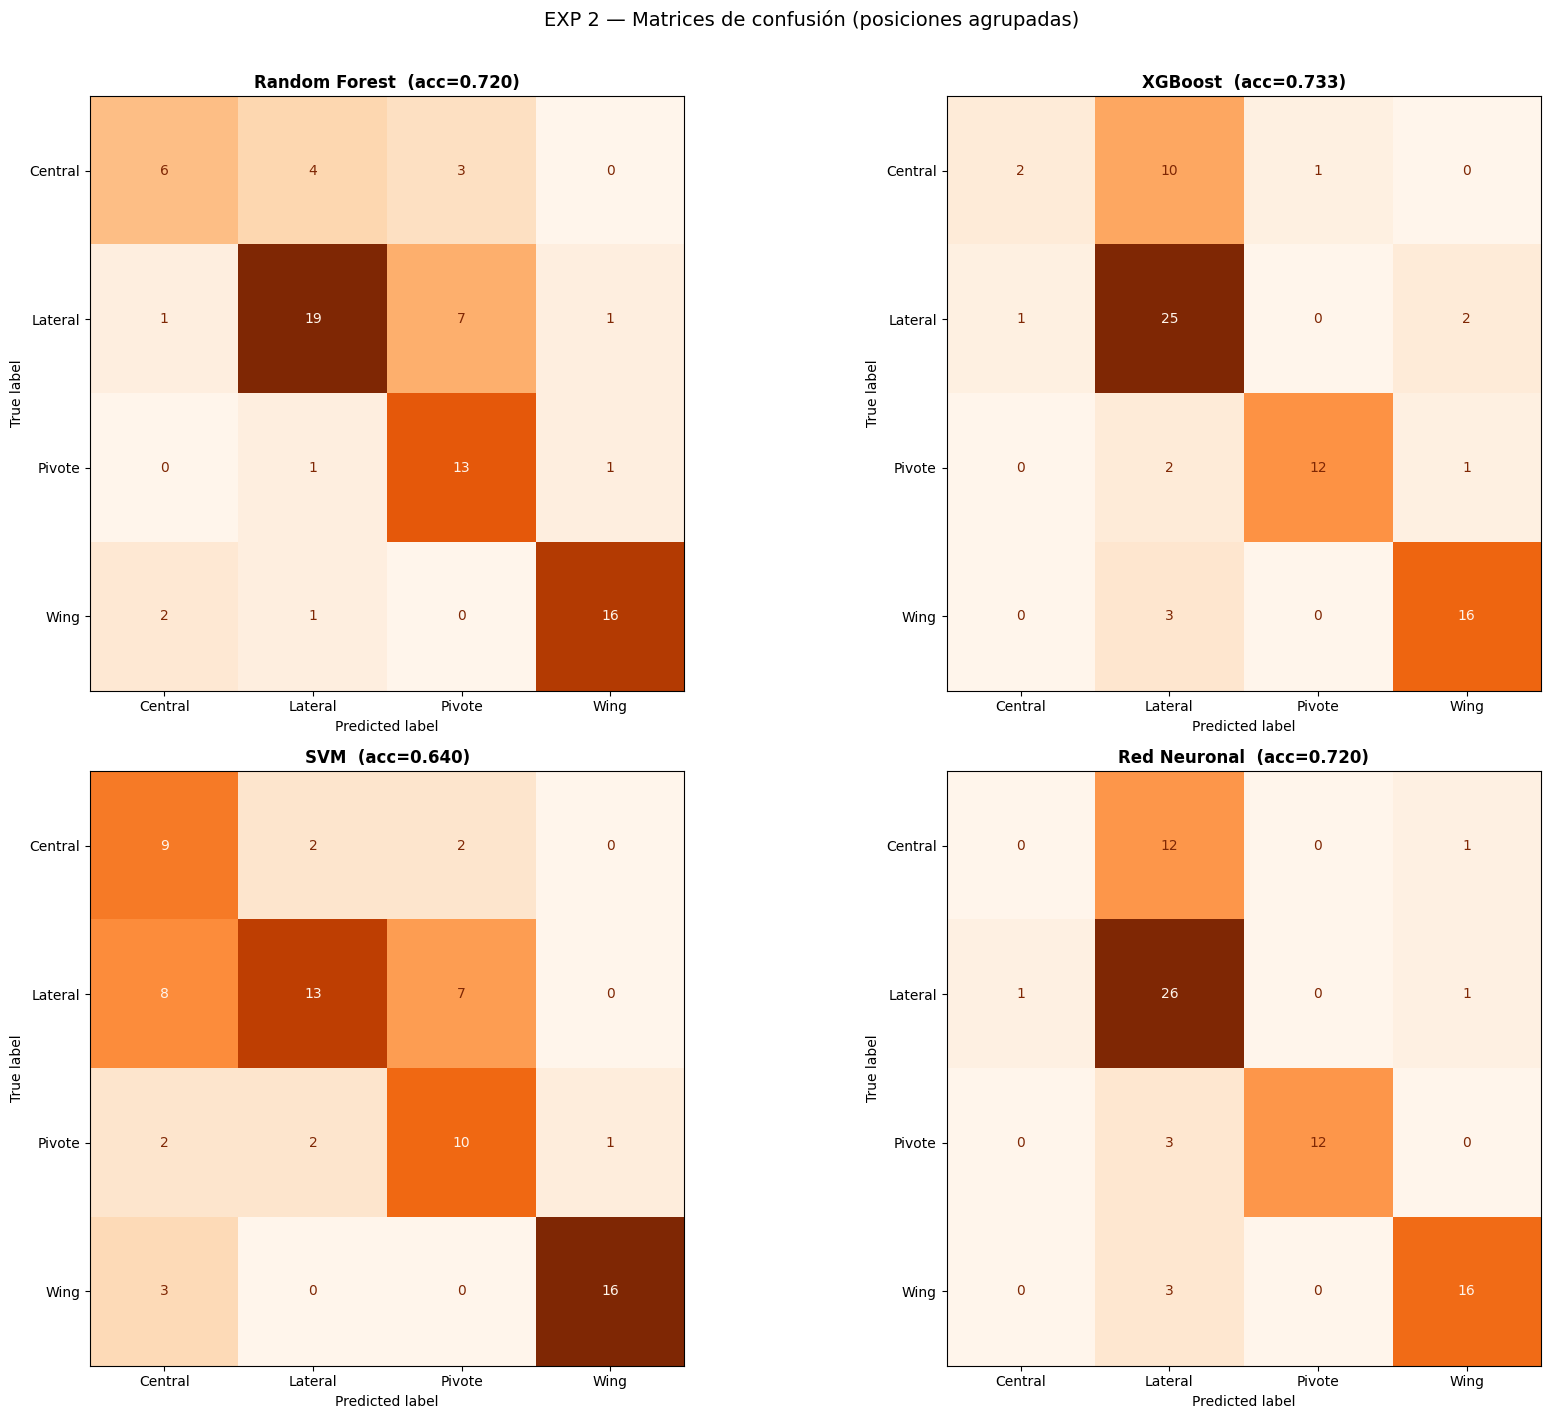

Guardada figura combinada: position_output/exp2/confusion_matrices_all.png


In [20]:
models_exp2 = [
    ('Random Forest', y2_pred_rf),
    ('XGBoost',       y2_pred_xgb),
    ('SVM',           y2_pred_svm),
    ('Red Neuronal',  y2_pred_mlp),
]

for name, preds in models_exp2:
    path = f"{OUT_ROOT}/exp2/cm_{name.replace(' ','_').lower()}.png"
    save_confusion_matrix(y2_test, preds, le2, f'EXP2 — {name}', path)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
for ax, (name, preds) in zip(axes, models_exp2):
    cm = confusion_matrix(y2_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le2.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    acc = accuracy_score(y2_test, preds)
    ax.set_title(f'{name}  (acc={acc:.3f})', fontsize=12, fontweight='bold')
plt.suptitle('EXP 2 — Matrices de confusión (posiciones agrupadas)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/confusion_matrices_all.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Guardada figura combinada: {OUT_ROOT}/exp2/confusion_matrices_all.png")

### 2.7 Tabla de métricas — EXP 2

In [21]:
cvs2 = [
    (cv_rf2.mean(),  cv_rf2.std()),
    (cv_xgb2.mean(), cv_xgb2.std()),
    (cv_svm2.mean(), cv_svm2.std()),
    (cv_mlp2.mean(), cv_mlp2.std()),
]

rows_exp2 = []
for (name, preds), (cv_m, cv_s) in zip(models_exp2, cvs2):
    rows_exp2.append(metrics_table(y2_test, preds, le2, name, cv_m, cv_s))

df_metrics_exp2 = pd.DataFrame(rows_exp2).set_index('Modelo')
print('=== EXP 2 — Métricas globales ===')
display(df_metrics_exp2)
df_metrics_exp2.to_csv(f'{OUT_ROOT}/exp2/metrics_global.csv')

rows_class_exp2 = []
for name, preds in models_exp2:
    rows_class_exp2.extend(per_class_table(y2_test, preds, le2, name))
df_class_exp2 = pd.DataFrame(rows_class_exp2)
print('\n=== EXP 2 — Métricas por clase ===')
display(df_class_exp2)
df_class_exp2.to_csv(f'{OUT_ROOT}/exp2/metrics_per_class.csv', index=False)

=== EXP 2 — Métricas globales ===


,Accuracy,F1 (weighted),F1 (macro),Precision (weighted),Recall (weighted)
Modelo,,,,,
Random Forest,0.7200,0.7182,0.7029,0.7375,0.7200
XGBoost,0.7333,0.7026,0.6711,0.7468,0.7333
SVM,0.6400,0.6477,0.6423,0.7001,0.6400
Red Neuronal,0.7200,0.6665,0.6190,0.6458,0.7200



=== EXP 2 — Métricas por clase ===


,Modelo,Clase,Precision,Recall,F1-score
0,Random Forest,Central,0.6667,0.4615,0.5455
1,Random Forest,Lateral,0.7600,0.6786,0.7170
2,Random Forest,Pivote,0.5652,0.8667,0.6842
3,Random Forest,Wing,0.8889,0.8421,0.8649
4,XGBoost,Central,0.6667,0.1538,0.2500
5,XGBoost,Lateral,0.6250,0.8929,0.7353
6,XGBoost,Pivote,0.9231,0.8000,0.8571
7,XGBoost,Wing,0.8421,0.8421,0.8421
8,SVM,Central,0.4091,0.6923,0.5143
9,SVM,Lateral,0.7647,0.4643,0.5778


### 2.8 Análisis SHAP — EXP 2 (mejor modelo)

Mejor modelo EXP2: XGBoost  (0.7333)


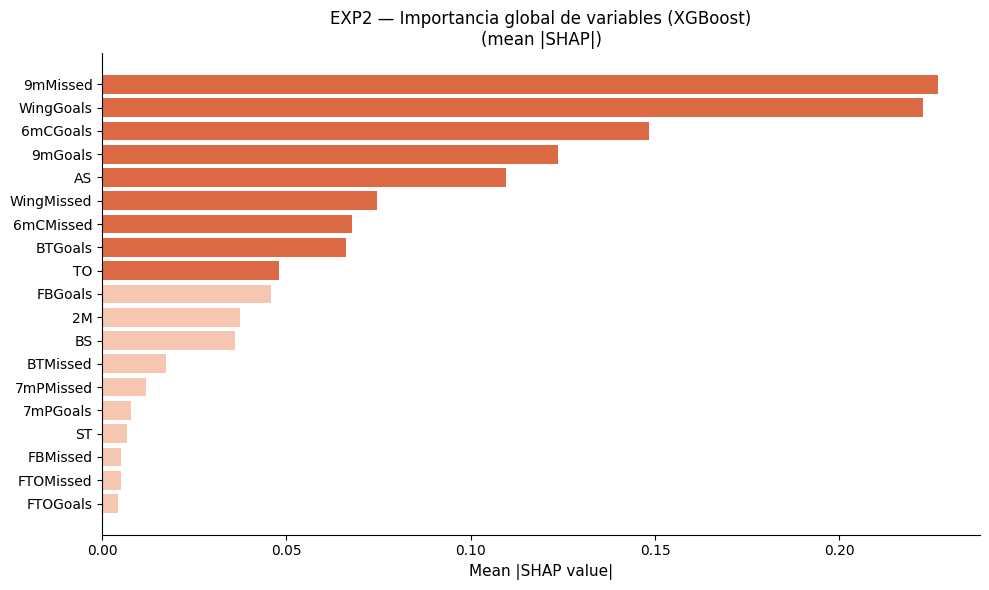


Top 10 variables más importantes (EXP2):


,mean_abs_shap
9mMissed,0.2268
WingGoals,0.2228
6mCGoals,0.1484
9mGoals,0.1237
AS,0.1097
WingMissed,0.0747
6mCMissed,0.0678
BTGoals,0.0663
TO,0.0480
FBGoals,0.0458


In [22]:
accs2 = {name: accuracy_score(y2_test, p) for name, p in models_exp2}
best_name2 = max(accs2, key=accs2.get)
best_model2_map = {'Random Forest': rf2, 'XGBoost': xgb2}
shap_model2_name = best_name2 if best_name2 in best_model2_map else 'XGBoost'
shap_model2 = best_model2_map[shap_model2_name]
print(f'Mejor modelo EXP2: {best_name2}  ({accs2[best_name2]:.4f})')

X2_all_sc = scaler2.transform(X2)
explainer2 = shap.TreeExplainer(shap_model2)
shap_vals2 = explainer2.shap_values(X2_all_sc)

if isinstance(shap_vals2, list):
    global_shap2 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals2], axis=0)
else:
    global_shap2 = np.abs(shap_vals2).mean(axis=(0, 2)) if shap_vals2.ndim == 3 else np.abs(shap_vals2).mean(axis=0)

shap_imp2 = pd.Series(global_shap2, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar2 = ['#d85a30' if v > shap_imp2.median() else '#f5c0a8' for v in shap_imp2.values]
ax.barh(shap_imp2.index[::-1], shap_imp2.values[::-1], color=colors_bar2[::-1], alpha=0.9)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title(f'EXP2 — Importancia global de variables ({shap_model2_name})\n(mean |SHAP|)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/shap_global_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nTop 10 variables más importantes (EXP2):')
display(shap_imp2.head(10).to_frame('mean_abs_shap').round(4))

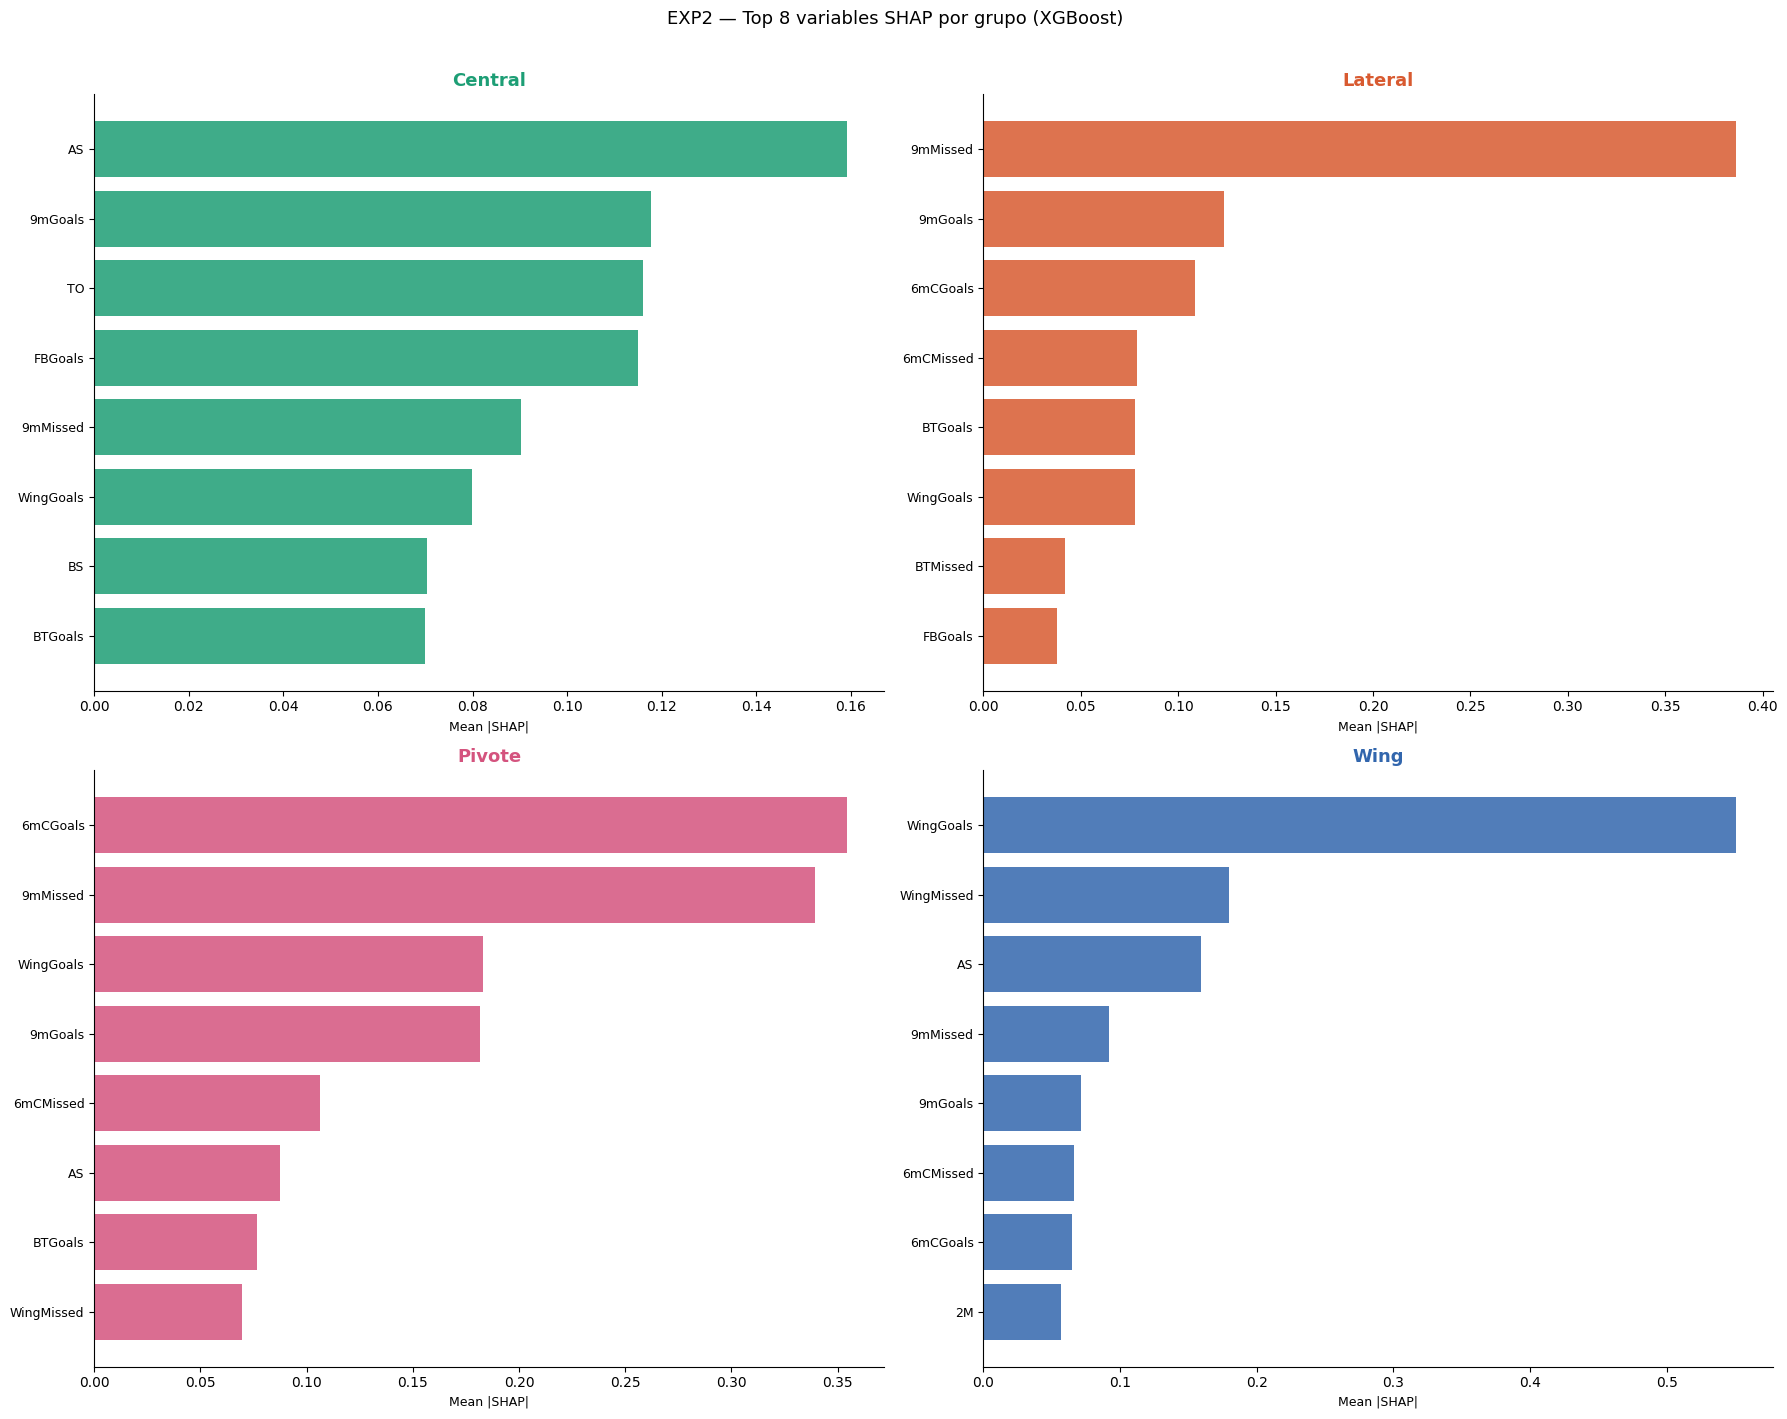

Guardada: position_output/exp2/shap_per_group.png


In [23]:
# SHAP por grupo — EXP2
if isinstance(shap_vals2, list):
    shap_list2 = shap_vals2
elif shap_vals2.ndim == 3:
    shap_list2 = [shap_vals2[:, :, i] for i in range(shap_vals2.shape[2])]
else:
    shap_list2 = [shap_vals2]

classes2 = le2.classes_
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, cls in enumerate(classes2):
    sv = shap_list2[idx]
    mean_abs = np.abs(sv).mean(axis=0)
    importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
    top_vars = importance.head(TOP_N)
    color = POS_COLORS.get(cls, '#888')
    ax = axes[idx]
    ax.barh(range(TOP_N), top_vars.values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.set_title(f'{cls}', fontsize=13, fontweight='bold', color=color)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'EXP2 — Top {TOP_N} variables SHAP por grupo ({shap_model2_name})',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/shap_per_group.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/shap_per_group.png')

---

# ══════════════════════════════════════════
# COMPARATIVA ENTRE EXPERIMENTOS
# ══════════════════════════════════════════

  RESUMEN COMPARATIVO DE EXPERIMENTOS

--- EXP 1 (6 clases) ---


,Accuracy,F1 (weighted),F1 (macro)
Modelo,,,
Random Forest,0.4133,0.4089,0.3879
XGBoost,0.4533,0.4291,0.3956
SVM,0.3867,0.3937,0.3758
Red Neuronal,0.4533,0.4150,0.3776



--- EXP 2 (4 clases) ---


,Accuracy,F1 (weighted),F1 (macro)
Modelo,,,
Random Forest,0.7200,0.7182,0.7029
XGBoost,0.7333,0.7026,0.6711
SVM,0.6400,0.6477,0.6423
Red Neuronal,0.7200,0.6665,0.6190


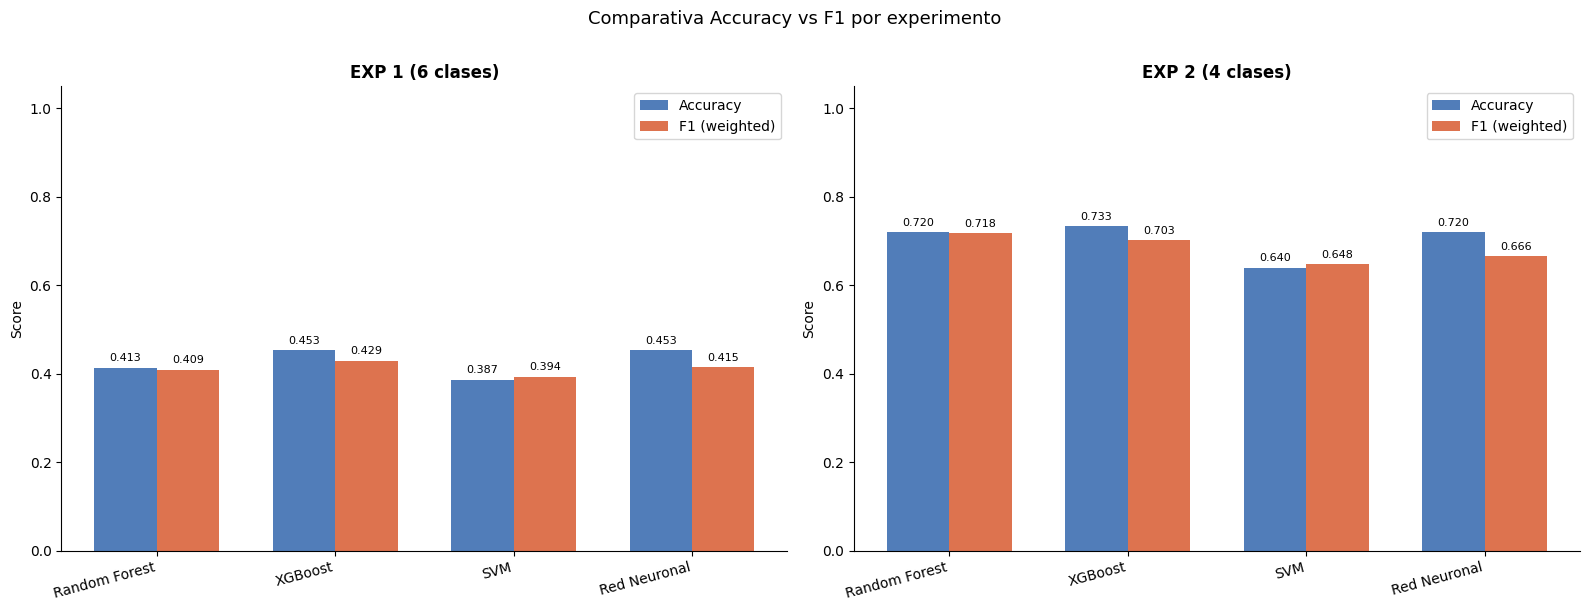

Guardada: position_output/comparativa_experimentos.png


In [24]:
print('=' * 55)
print('  RESUMEN COMPARATIVO DE EXPERIMENTOS')
print('=' * 55)
print('\n--- EXP 1 (6 clases) ---')
display(df_metrics_exp1[['Accuracy', 'F1 (weighted)', 'F1 (macro)']])

print('\n--- EXP 2 (4 clases) ---')
display(df_metrics_exp2[['Accuracy', 'F1 (weighted)', 'F1 (macro)']])

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
for ax, (df_met, title) in zip(axes, [
    (df_metrics_exp1, 'EXP 1 (6 clases)'),
    (df_metrics_exp2, 'EXP 2 (4 clases)'),
]):
    x = range(len(df_met))
    width = 0.35
    bars1 = ax.bar([i - width/2 for i in x], df_met['Accuracy'],
                   width, label='Accuracy', color='#3266ad', alpha=0.85)
    bars2 = ax.bar([i + width/2 for i in x], df_met['F1 (weighted)'],
                   width, label='F1 (weighted)', color='#d85a30', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_met.index, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparativa Accuracy vs F1 por experimento', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/comparativa_experimentos.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/comparativa_experimentos.png')

---

# ══════════════════════════════════════════
# MODELO FINAL
# Entrenar con el 100% de los datos (train+test)
# 
# ══════════════════════════════════════════

In [25]:
# ── EXP 1 — Modelo final sobre todos los datos─────
print('=== MODELO FINAL — EXP 1 (sin GK) ===')

X1_all_full = df_exp1[FEATURE_COLS].values
y1_all_full = le1.transform(df_exp1[TARGET_COL].values)

scaler1_final = StandardScaler()
X1_all_sc_final = scaler1_final.fit_transform(X1_all_full)

# Usamos los mejores hiperparámetros encontrados en el experimento
rf1_final = RandomForestClassifier(
    **gs_rf1.best_params_,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf1_final.fit(X1_all_sc_final, y1_all_full)
print(f'RF EXP1 final entrenado con {len(y1_all_full)} instancias. Clases: {le1.classes_}')

# ── EXP 2 — Modelo final sobre todos los datos (grupos) ─────
print('\n=== MODELO FINAL — EXP 2 (agrupado) ===')

X2_all_full = df_exp2[FEATURE_COLS].values
y2_all_full = le2.transform(df_exp2['Grupo'].values)

scaler2_final = StandardScaler()
X2_all_sc_final = scaler2_final.fit_transform(X2_all_full)

rf2_final = RandomForestClassifier(
    **gs_rf2.best_params_,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf2_final.fit(X2_all_sc_final, y2_all_full)
print(f'RF EXP2 final entrenado con {len(y2_all_full)} instancias. Clases: {le2.classes_}')

=== MODELO FINAL — EXP 1 (sin GK) ===
RF EXP1 final entrenado con 371 instancias. Clases: ['CB' 'LB' 'LP' 'LW' 'RB' 'RW']

=== MODELO FINAL — EXP 2 (agrupado) ===
RF EXP2 final entrenado con 371 instancias. Clases: ['Central' 'Lateral' 'Pivote' 'Wing']


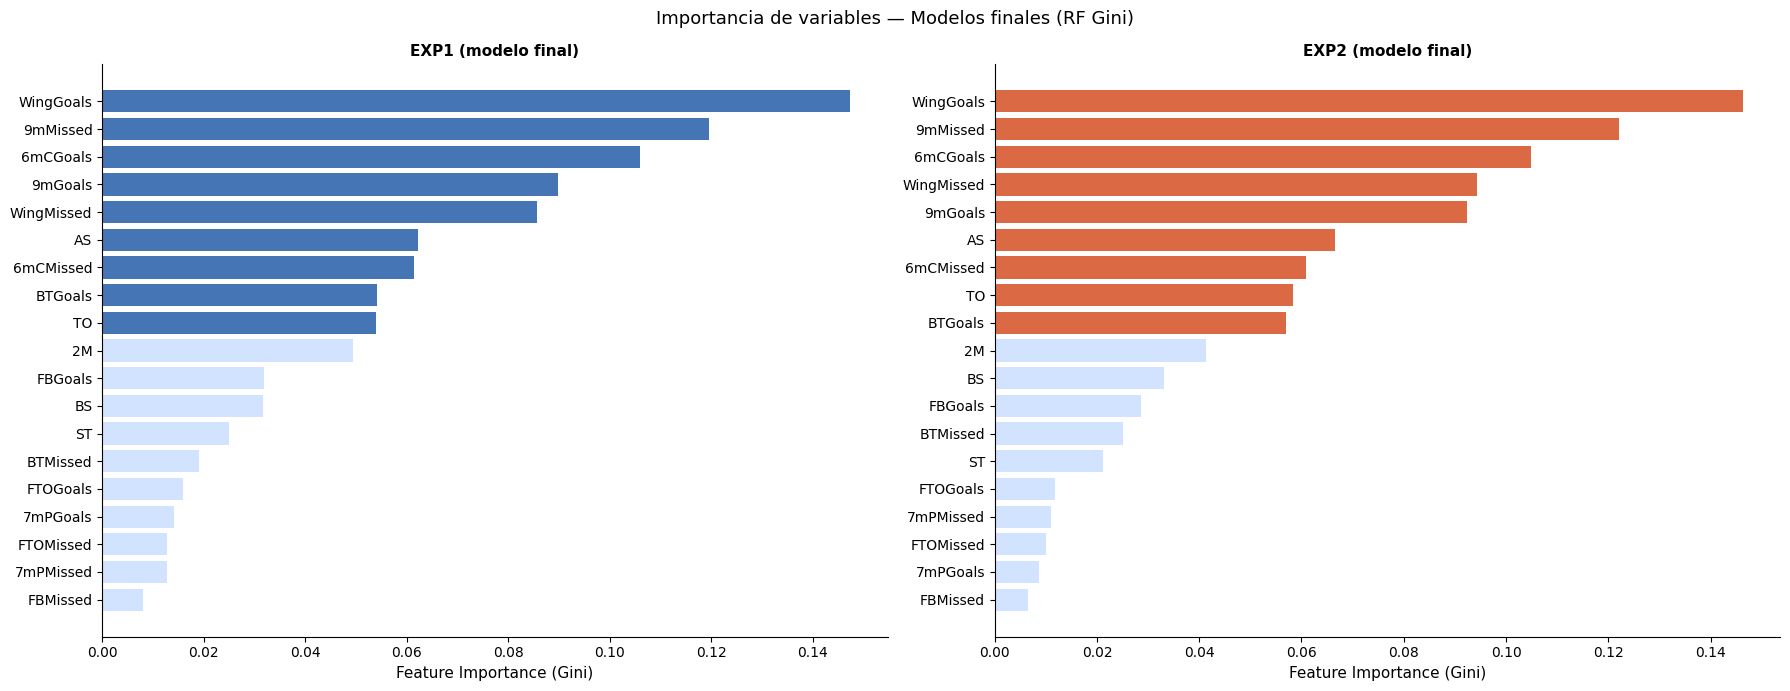

Guardada: position_output/final/feature_importance_final.png

Notebook completado exitosamente.
Todos los artefactos en: position_output/


In [26]:
# ── Importancia de variables del modelo final (RF, Gini) ────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (rf_fin, scaler_fin, title_exp, color_bar) in zip(axes, [
    (rf1_final, scaler1_final, 'EXP1 (modelo final)', '#3266ad'),
    (rf2_final, scaler2_final, 'EXP2 (modelo final)', '#d85a30'),
]):
    imp = pd.Series(rf_fin.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    colors_imp = [color_bar if v > imp.median() else '#cce0ff' for v in imp.values]
    ax.barh(imp.index[::-1], imp.values[::-1], color=colors_imp[::-1], alpha=0.9)
    ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
    ax.set_title(title_exp, fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Importancia de variables — Modelos finales (RF Gini)', fontsize=13)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/final/feature_importance_final.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/final/feature_importance_final.png')

print('\nNotebook completado exitosamente.')
print(f'Todos los artefactos en: {OUT_ROOT}/')